<a href="https://colab.research.google.com/github/awilb12/Intro_Week1/blob/main/matplotlibpractice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#! /bin/python3

In [ ]:
import matplotlib

In [ ]:
import re

In [ ]:
import sys

In [ ]:
import os

In [ ]:
print(os.getcwd())

/content


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
infile = open("../ntl_icecover.csv")
data = pd.read_csv("../ntl_icecover.csv")
print(data.head())
infile.close()

         lakeid      ice_on     ice_off  ice_duration  year
0  Lake Mendota         NaN  1853-04-05           NaN  1852
1  Lake Mendota  1853-12-27         NaN           NaN  1853
2  Lake Mendota  1855-12-18  1856-04-14         118.0  1855
3  Lake Mendota  1856-12-06  1857-05-06         151.0  1856
4  Lake Mendota  1857-11-25  1858-03-26         121.0  1857


In [ ]:
import pandas as pd

data = pd.read_csv("../ntl_icecover.csv")

In [ ]:
years = data["year"]
durations = data["ice_duration"]
lakes = data["lakeid"]
dc = data["lakeid"], data["ice_duration"], data["year"]
print(dc)

(0      Lake Mendota
1      Lake Mendota
2      Lake Mendota
3      Lake Mendota
4      Lake Mendota
           ...     
329     Lake Monona
330     Lake Monona
331     Lake Monona
332     Lake Monona
333     Lake Monona
Name: lakeid, Length: 334, dtype: object, 0        NaN
1        NaN
2      118.0
3      151.0
4      121.0
       ...  
329     62.0
330     81.0
331     93.0
332     97.0
333     80.0
Name: ice_duration, Length: 334, dtype: float64, 0      1852
1      1853
2      1855
3      1856
4      1857
       ... 
329    2015
330    2016
331    2017
332    2018
333    2019
Name: year, Length: 334, dtype: int64)


In [ ]:
infile = open("../ntl_icecover.csv")
lake_mendota = re.findall(r"Lake Mendota.*\n", infile.read())
print(lake_mendota)
infile.close()

infile = open("../ntl_icecover.csv")
lake_monona = re.findall(r"Lake Monona.*\n", infile.read())
print(lake_monona)
infile.close()

['Lake Mendota",NA,1853-04-05,NA,1852\n', 'Lake Mendota",1853-12-27,NA,NA,1853\n', 'Lake Mendota",1855-12-18,1856-04-14,118,1855\n', 'Lake Mendota",1856-12-06,1857-05-06,151,1856\n', 'Lake Mendota",1857-11-25,1858-03-26,121,1857\n', 'Lake Mendota",1858-12-08,1859-03-14,96,1858\n', 'Lake Mendota",1859-12-07,1860-03-26,110,1859\n', 'Lake Mendota",1860-12-14,1861-04-10,117,1860\n', 'Lake Mendota",1861-12-02,1862-04-13,132,1861\n', 'Lake Mendota",1862-12-26,1863-04-09,104,1862\n', 'Lake Mendota",1863-12-18,1864-04-21,125,1863\n', 'Lake Mendota",1864-12-08,1865-04-05,118,1864\n', 'Lake Mendota",1865-12-14,1866-04-18,125,1865\n', 'Lake Mendota",1866-12-18,1867-04-20,123,1866\n', 'Lake Mendota",1867-12-12,1868-03-31,110,1867\n', 'Lake Mendota",1868-12-10,1869-04-16,127,1868\n', 'Lake Mendota",1869-12-02,1870-04-12,131,1869\n', 'Lake Mendota",1870-12-24,1871-04-02,99,1870\n', 'Lake Mendota",1871-12-19,1872-04-23,126,1871\n', 'Lake Mendota",1872-11-30,1873-04-23,144,1872\n', 'Lake Mendota",1873

In [ ]:
monona = data[data["lakeid"] == "Lake Monona"]

mendota = data[data["lakeid"] == "Lake Mendota"]

In [ ]:
monona_years = monona["year"]

monona_duration = monona["ice_duration"]

mendota_years = mendota["year"]

mendota_duration = mendota["ice_duration"]

In [ ]:
import numpy as np
x1 = np.array(monona_years)
y1 = np.array(monona_duration)

mask1 = ~np.isnan(x1) & ~np.isnan(y1) #This is essential for the best fit line to actually show up
                                      #Since the data contained 'NaN' data points, the best fit line would break
                                      #This short line of code masks the 'NaN' data points allowing for the best fit line to function properly
x1, y1 = x1[mask1], y1[mask1]

coeffs1 = np.polyfit(x1, y1, deg=1)   #This creates the coefficients using our data points
best_fit1 = np.poly1d(coeffs1)        #This loads the best fit line based on our coefficients so all we have to do is graph it.
                                      #This was troubleshooted using Claude AI

x2 = np.array(mendota_years)
y2 = np.array(mendota_duration)

mask2 = ~np.isnan(x2) & ~np.isnan(y2)
x2, y2 = x2[mask2], y2[mask2]

coeffs2 = np.polyfit(x2, y2, deg=1)
best_fit2 = np.poly1d(coeffs2)

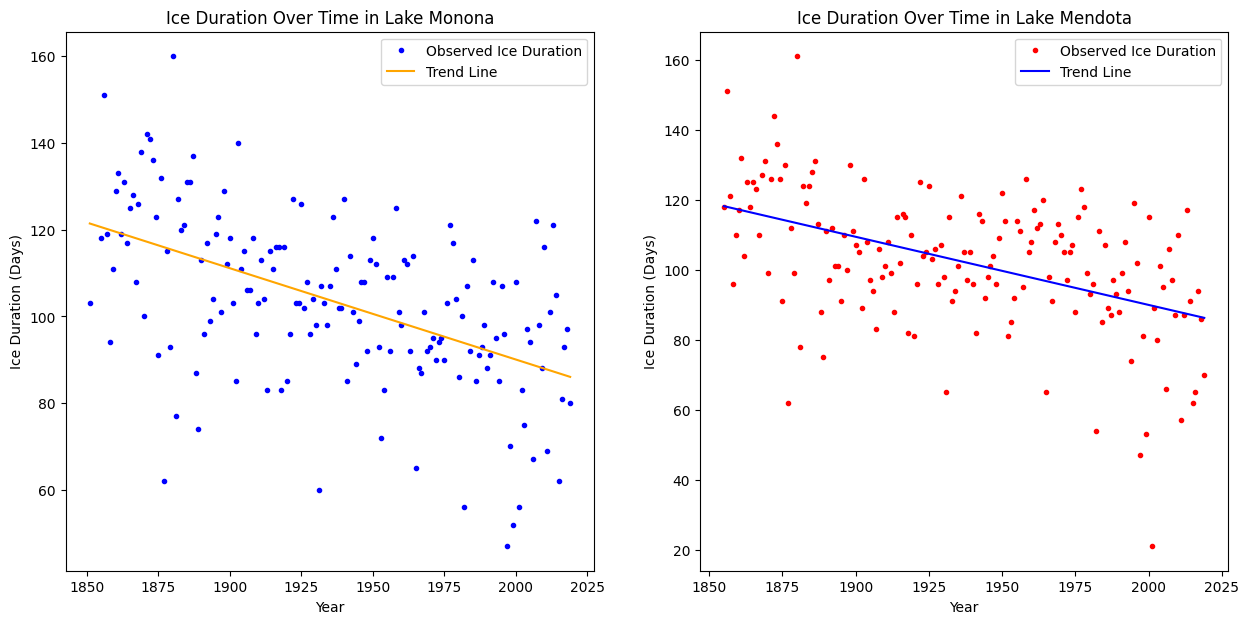

In [ ]:
plt.figure(figsize=(15,7))

plt.subplot(121)
plt.title("Ice Duration Over Time in Lake Monona")
plt.ylabel("Ice Duration (Days)")
plt.xlabel("Year")
# Plot the scatter points
plt.plot(monona_years, monona_duration, 'bo', markersize=3, label='Observed Ice Duration')
# Plot the best fit line
plt.plot(x1, best_fit1(x1), color='orange', label='Trend Line')
plt.legend()

plt.subplot(122)
plt.title("Ice Duration Over Time in Lake Mendota")
plt.ylabel("Ice Duration (Days)")
plt.xlabel("Year")
# Plot the scatter points
plt.plot(mendota_years, mendota_duration,'ro',markersize=3, label='Observed Ice Duration')
# Plot the best fit line
plt.plot(x2, best_fit2(x2), color='blue', label='Trend Line')
plt.legend()

plt.show()